In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
from scipy.optimize import least_squares
from tqdm.auto import tqdm
import lal
lal.swig_redirect_standard_output_error(True)


/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [100]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.30_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [101]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


### 0PN binding energy and total angular momentum

In this cell we construct the Newtonian orbital binding energy and the total angular momentum of a compact binary system at 0PN order. We keep explicit powers of the speed of light $c$ only as a bookkeeping device for the spin contribution to the total angular momentum.

The PN bookkeeping parameter is

$$
\epsilon = \frac{1}{c}.
$$

The standard dimensionless PN expansion parameter is

$$
x_{\rm PN} = \left(\frac{Gm\Omega}{c^3}\right)^{2/3},
$$

where $\Omega$ is the orbital frequency and $m=m_1+m_2$ is the total mass. In the symbolic calculation we introduce the rescaled variable $X$, defined by

$$
X = c^2 x_{\rm PN}.
$$

Equivalently,

$$
x_{\rm PN} = \frac{X}{c^2} = X\epsilon^2.
$$

At 0PN order, the non-spinning binding energy is simply the Newtonian orbital energy,

$$
E_{\rm bind}^{0PN}(X) = -\frac{\mu X}{2}.
$$

The mass parameters are

$$
m = m_1+m_2,
\qquad
\mu = \frac{m_1m_2}{m},
\qquad
\nu = \frac{\mu}{m}.
$$

Here $m$ is the total mass, $\mu$ is the reduced mass, and $\nu$ is the symmetric mass ratio. At 0PN order there are no point-particle corrections proportional to $1/c^2$.

The corresponding Newtonian orbital angular momentum is

$$
L_{\rm orb}^{0PN}(X) = \frac{G\mu m}{\sqrt{X}}.
$$

The orbital angular momentum is assumed to be aligned with the instantaneous orbital direction $\boldsymbol{\ell}$. The spins are decomposed on the orbital triad $(\mathbf n,\boldsymbol{\lambda},\boldsymbol{\ell})$ as

$$
\mathbf S_i = S_{in}\mathbf n + S_{i\lambda}\boldsymbol{\lambda} + S_{iL}\boldsymbol{\ell}.
$$

Therefore, the components of the total angular momentum are

$$
J_\ell = L_{\rm orb}^{0PN} + \frac{S_{1L}+S_{2L}}{c},
$$

$$
J_n = \frac{S_{1n}+S_{2n}}{c},
$$

$$
J_\lambda = \frac{S_{1\lambda}+S_{2\lambda}}{c}.
$$

The magnitude of the total angular momentum is

$$
J_{\rm tot} = \sqrt{J_\ell^2+J_n^2+J_\lambda^2}.
$$

Expanding $J_{\rm tot}$ in powers of $\epsilon=1/c$ gives the Newtonian orbital contribution, the leading spin projection along $\boldsymbol{\ell}$, and the first correction induced by the transverse spin components. In the numerical 0PN implementation, this vector norm is evaluated directly in geometric units, $G=c=m=1$.

In terms of the separation variable used in the numerical evolution,

$$
a = \frac{r}{m},
\qquad
X = \gamma = \frac{1}{a},
$$

so that

$$
E_{\rm bind}^{0PN}(a) = -\frac{\eta}{2a},
\qquad
L_{\rm orb}^{0PN}(a) = \eta\sqrt{a},
$$

where $\eta=\mu/m$.

The total mass entering the Kerr entropy is then reconstructed as

$$
M_{\rm tot} = 1+E_{\rm bind}^{0PN}
$$

in geometric units.

**References**

* L. Blanchet, *Post-Newtonian Theory for Gravitational Waves*, Living Reviews in Relativity **17**, 2 (2014), arXiv:1310.1528.
* L. E. Kidder, *Coalescing binary systems of compact objects to post-Newtonian 5/2 order. V. Spin effects*, Physical Review D **52**, 821 (1995), arXiv:gr-qc/9506022.


In [102]:
c = sp.Symbol('c', positive=True)
eps = sp.Symbol('eps', positive=True)

G = sp.Symbol('G', real=True, positive=True)
nu = sp.Symbol(r'\nu', real=True, positive=True)
mu = sp.Symbol(r'\mu', real=True, positive=True)
m = sp.Symbol('m', real=True, positive=True)
m1, m2 = sp.symbols('m_1 m_2', positive=True)

S1n, S2n = sp.symbols(r'S_{1n} S_{2n}', real=True)
S1lam, S2lam = sp.symbols(r'S_{1\lambda} S_{2\lambda}', real=True)
S1L, S2L = sp.symbols(r'S_{1L} S_{2L}', real=True)
X = sp.Symbol('X', real=True, positive=True)
x_val = X * eps**2
E_NS = -mu * (1 / eps)**2 * x_val / 2
L_NS = G * mu * m / ((1 / eps) * sp.sqrt(x_val))
E_0PN_NS = sp.expand(E_NS)
L_0PN_NS = sp.expand(L_NS)
E_tot = E_0PN_NS
L_ell_tot = L_0PN_NS
L_n_tot = 0
L_lam_tot = 0
J_ell = L_ell_tot + eps * (S1L + S2L)
J_n = L_n_tot + eps * (S1n + S2n)
J_lam = L_lam_tot + eps * (S1lam + S2lam)
J_tot = sp.sqrt(J_ell**2 + J_n**2 + J_lam**2)
E_tot_eps = sp.series(E_tot, eps, 0, 3).removeO()
J_tot_eps = sp.series(J_tot, eps, 0, 3).removeO()

def get_eps_terms(expr, max_power=2):
    
    expr = sp.expand(expr)
    terms = {}

    for power in range(max_power + 1):

        coeff = sp.expand(expr).coeff(eps, power)

        if coeff != 0:
            terms[power] = sp.simplify(coeff)

    return terms

def pn_label_from_eps_power(power):
    
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"S_\perp^2/c^2",
    }

    return labels.get(power, rf"\epsilon^{power}")

def display_pn_terms(name, expr_eps, max_power=2):
    
    terms = get_eps_terms(expr_eps, max_power=max_power)

    lines = []
    total_terms = []

    for power, coeff in terms.items():

        term_with_c = coeff / c**power
        total_terms.append(term_with_c)

        label = pn_label_from_eps_power(power)

        lines.append(
            rf"{name}_{{{label}}} &= {sp.latex(term_with_c)}"
        )

    total_expr = sp.Add(*total_terms, evaluate=False)

    lines.append(
        rf"{name} &= {sp.latex(total_expr)}"
    )

    latex_str = r"\begin{aligned}" + r"\\".join(lines) + r"\end{aligned}"

    display(Math(latex_str))

    print("\n" + "-"*80 + "\n")

print(r"1. Total binding energy at 0PN:" + "\n")
display_pn_terms(r"E_{\rm bind}^{0PN}(X)", E_tot_eps, max_power=2)
print(r"2. Total angular momentum with 0PN orbital dynamics:" + "\n")
display_pn_terms(r"J_{\rm tot}^{0PN}(X)", J_tot_eps, max_power=2)

1. Total binding energy at 0PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------

2. Total angular momentum with 0PN orbital dynamics:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------



In [103]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [104]:
def get_0PN_precessing(q_prec, chi1_vecs, chi2_vecs, a_arr):
   
    a_arr = np.asarray(a_arr, dtype=float)
    chi1_vecs = np.asarray(chi1_vecs, dtype=float)
    chi2_vecs = np.asarray(chi2_vecs, dtype=float)

    if np.any(a_arr <= 0):
        raise ValueError("All separation values must be positive.")

    m1 = 1.0 / (1.0 + q_prec)
    m2 = q_prec / (1.0 + q_prec)
    eta = m1 * m2

    gamma = 1.0 / a_arr

    E_bind = -0.5 * eta * gamma
    M_tot = 1.0 + E_bind

    L_orb_mag = eta / np.sqrt(gamma)

    L_vecs = np.zeros((3, len(a_arr)))
    L_vecs[2, :] = L_orb_mag

    S_tot_vecs = chi1_vecs * m1**2 + chi2_vecs * m2**2

    J_vecs = L_vecs + S_tot_vecs
    J_tot_mag = np.linalg.norm(J_vecs, axis=0)

    S_inst = entropy(M_tot, J_tot_mag)

    return {
        "q_prec": q_prec,
        "m1": m1,
        "m2": m2,
        "eta": eta,
        "a": a_arr,
        "gamma": gamma,
        "E_bind": E_bind,
        "M_tot": M_tot,
        "L_orb_mag": L_orb_mag,
        "L_vecs": L_vecs,
        "S_tot_vecs": S_tot_vecs,
        "J_vecs": J_vecs,
        "J_tot_mag": J_tot_mag,
        "S_inst": S_inst
    }

In [105]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):
    
    if q_prec < 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = np.asarray(chi2_0_vec, dtype=float)
        chi_surr_2 = np.asarray(chi1_0_vec, dtype=float)
    else:
        q_surr = q_prec
        chi_surr_1 = np.asarray(chi1_0_vec, dtype=float)
        chi_surr_2 = np.asarray(chi2_0_vec, dtype=float)
        
    chi_surr_1 = chi_surr_1.flatten()
    chi_surr_2 = chi_surr_2.flatten()

    t, h, _ = sur_wave_precessing(
        q_surr,
        chi_surr_1,
        chi_surr_2,
        dt=0.1,
        f_low=f_low
    )

    amp_tot_sq = np.zeros_like(t, dtype=float)

    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode

        h_lm = np.asarray(h_lm, dtype=complex)

        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq

        if m == 0:
            continue

        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))

        omega_orb_lm = omega_lm / abs(m)

        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)

    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask = omega_orb_den > 0.0
    omega_orb[mask] = omega_orb_num[mask] / omega_orb_den[mask]

    r_inst = np.full_like(t, np.nan, dtype=float)
    mask = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask] = omega_orb[mask]**(-2.0 / 3.0)

    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    return r_merger, t, r_inst

In [106]:
def get_merger_separation_NR_1(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):

    q_prec = float(q_prec)
    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float).flatten()
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float).flatten()

    if chi1_0_vec.shape != (3,):
        raise ValueError(f"chi1_0_vec must have shape (3,), got {chi1_0_vec.shape}.")
    if chi2_0_vec.shape != (3,):
        raise ValueError(f"chi2_0_vec must have shape (3,), got {chi2_0_vec.shape}.")
    if q_prec <= 0:
        raise ValueError("q_prec must be positive.")
    if q_prec <= 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec
    else:
        q_surr = q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec

    t, h, _ = sur_wave_precessing(q_surr,chi_surr_1,chi_surr_2,dt=0.1,f_low=f_low)
    amp_tot_sq = np.zeros_like(t, dtype=float)
    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode
        h_lm = np.asarray(h_lm, dtype=complex)
        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq
        if m == 0:
            continue
        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))
        omega_orb_lm = omega_lm / abs(m)
        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)
    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask_omega = omega_orb_den > 0.0
    omega_orb[mask_omega] = omega_orb_num[mask_omega] / omega_orb_den[mask_omega]
    r_inst = np.full_like(t, np.nan, dtype=float)
    mask_r = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask_r] = omega_orb[mask_r]**(-2.0 / 3.0)
    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    if not np.isfinite(r_merger):
        finite_idx = np.where(np.isfinite(r_inst))[0]
        if len(finite_idx) == 0:
            raise RuntimeError("No finite effective separation could be computed.")
        nearest = finite_idx[np.argmin(np.abs(finite_idx - idx_merger))]
        r_merger = r_inst[nearest]

    return r_merger, t, r_inst

In [107]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [108]:
with open(file_path, 'r') as f:
    f.readline() 
    header_line = f.readline() 

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))
theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad) 
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z]) 

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m2 = q_prec / (1.0 + q_prec)
m1 = 1.0 / (1.0 + q_prec)

In [109]:
# surrogate prediction
q_surr = 1/q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy (mf_surr, Jf_surr)
a_merger, t, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print (a_merger)
print (ent_surr)

3.133805714402399
10.70668988037251


In [110]:
res_0PN = get_0PN_precessing(q_prec, chi1_vec, chi2_vec, a_prec)
a_0PN = res_0PN["a"]
M_0PN = res_0PN["M_tot"]
J_0PN = res_0PN["J_tot_mag"]
S_0PN = res_0PN["S_inst"]

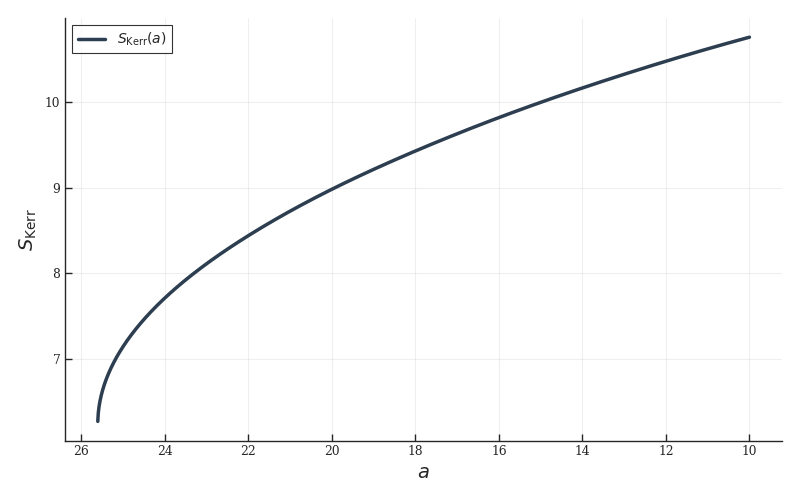

In [111]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_0PN, S_0PN, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"$a$") 
ax.set_ylabel(r"$S_{\rm Kerr}$") 
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()

plt.show()

Padè

### Padé $[2/1]$ extrapolation of the 0PN entropy curve

In this cell we extrapolate the 0PN entropy curve toward smaller separations using a Padé $[2/1]$ approximant. Starting from the valid 0PN data, we first select only physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}>0,
\qquad
|\chi|\leq 1.
$$

The fitting variable is chosen as

$$
x = \frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases. Instead of fitting the entropy directly, we fit separately the Newtonian binding energy

$$
E_{\rm bind}^{0PN}=M_{\rm tot}^{0PN}-m
$$

and the dimensionless Kerr spin parameter

$$
\chi^{0PN} = \frac{J_{\rm tot}^{0PN}}{\left(M_{\rm tot}^{0PN}\right)^2}.
$$

Both quantities are fitted with a Padé $[2/1]$ model,

$$
P_{[2/1]}(x) =
\frac{a_0+a_1x+a_2x^2}{1+b_1x}.
$$

The fit is performed with a least-squares routine using a `soft_l1` loss. Several initial guesses are tested through a multi-start procedure, and the solution with the smallest cost is retained. The weights are chosen as

$$
\sigma(a)=\left(\frac{a}{a_{\min}}\right),
$$

so that points at smaller separation have larger statistical weight in the fit.

After the extrapolation, the total mass and angular momentum are reconstructed as

$$
M_{\rm extrap}^{0PN}=m+E_{\rm bind,extrap}^{0PN},
$$

$$
J_{\rm extrap}^{0PN} =
\chi_{\rm extrap}^{0PN}
\left(M_{\rm extrap}^{0PN}\right)^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr} =
2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points with $M>0$ and $|\chi|\leq1$ are retained. The maximum of the extrapolated 0PN entropy curve defines

$$
a_{\max}^{0PN,{\rm Padé}},
$$

which is then compared with the merger separation inferred from the surrogate waveform,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a_{0PN} =
\left|
a_{\max}^{0PN,{\rm Padé}}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a 0PN baseline test of whether the maximum of the Newtonian extrapolated entropy curve occurs close to the surrogate merger separation. The comparison with the 1PN case then shows how much the inclusion of the first post-Newtonian orbital corrections shifts the predicted entropy maximum.


In [112]:
valid_mask = (np.isfinite(S_0PN)& np.isfinite(a_0PN)& np.isfinite(M_0PN)& np.isfinite(J_0PN)& (a_0PN > 0)& (M_0PN > 0))

a_valid = a_0PN[valid_mask]
M_valid = M_0PN[valid_mask]
J_valid = J_0PN[valid_mask]
S_valid = S_0PN[valid_mask]

sort_idx = np.argsort(a_valid)

a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S_valid[sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

try:
    m_ref = float(res_0PN["m"])
except Exception:
    try:
        m_ref = float(m1 + m2)
    except Exception:
        m_ref = 1.0

Ebind_fit = M_fit - m_ref
chi_fit = J_fit / M_fit**2

fit_mask = (np.isfinite(x_fit)& np.isfinite(Ebind_fit)& np.isfinite(chi_fit)& (np.abs(chi_fit) <= 1.0))

a_fit = a_fit[fit_mask]
x_fit = x_fit[fit_mask]
M_fit = M_fit[fit_mask]
J_fit = J_fit[fit_mask]
S_fit = S_fit[fit_mask]
Ebind_fit = Ebind_fit[fit_mask]
chi_fit = chi_fit[fit_mask]

a_min_fit = np.nanmin(a_fit)
sigma_fit = (a_fit / a_min_fit)**1.0




def pade_2_1_fit(
    x,
    y,
    sigma,
    y_scale=None,
    n_starts=10,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label="Padé [2/1] fit"
):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (np.isfinite(x)& np.isfinite(y)& np.isfinite(sigma)& (sigma > 0))

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if y_scale is None:
        y_scale = np.nanstd(y)

    if not np.isfinite(y_scale) or y_scale == 0:
        y_scale = 1.0

    lower_bounds = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)

    def residuals(params):
        y_model = pade_2_1(x, *params)
        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)
        return res

    rng = np.random.default_rng(random_seed)
    starts = []
    starts.append(np.array([np.nanmedian(y),0.0,0.0,0.1],dtype=float))

    for _ in range(n_starts - 1):

        starts.append(np.array([np.nanmedian(y),rng.normal(loc=0.0, scale=0.2 * y_scale),rng.normal(loc=0.0, scale=0.2 * y_scale),rng.uniform(low=0.0, high=1.0)],dtype=float))

    best_result = None
    best_cost = np.inf
    last_exception = None
    iterator = tqdm(starts,desc=progress_label,total=len(starts),leave=True)

    for p0 in iterator:

        try:
            res = least_squares(residuals,p0,bounds=(lower_bounds, upper_bounds),loss=loss,f_scale=f_scale,x_scale="jac",max_nfev=max_nfev)
            if res.success and np.isfinite(res.cost) and res.cost < best_cost:
                best_result = res
                best_cost = res.cost
            iterator.set_postfix(best_cost=f"{best_cost:.3e}")
        except Exception as exc:
            last_exception = exc
            iterator.set_postfix(error=str(exc)[:40])
            continue
    if best_result is None:
        raise RuntimeError(
            "0PN Padé [2/1] fit failed.\n"
            f"Last exception: {repr(last_exception)}"
        )
    return best_result.x, best_result


model_name = "0PN Padé [2/1]"

N_E_BIND = 20
N_CHI = 20

popt_Ebind, result_Ebind = pade_2_1_fit(
    x=x_fit,
    y=Ebind_fit,
    sigma=sigma_fit,
    y_scale=np.nanstd(Ebind_fit),
    n_starts=N_E_BIND,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label=r"Fitting 0PN E_bind with Padé [2/1]"
)

popt_chi, result_chi = pade_2_1_fit(
    x=x_fit,
    y=chi_fit,
    sigma=sigma_fit,
    y_scale=np.nanstd(chi_fit),
    n_starts=N_CHI,
    random_seed=4321,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=15000,
    progress_label=r"Fitting 0PN chi with Padé [2/1]"
)


a_extrap_0PN = np.linspace(15.0, 1.0, 10000)
x_extrap_0PN = 1.0 / np.sqrt(a_extrap_0PN)
Ebind_extrap_0PN = pade_2_1(x_extrap_0PN, *popt_Ebind)
chi_extrap_0PN = pade_2_1(x_extrap_0PN, *popt_chi)
M_extrap_0PN = m_ref + Ebind_extrap_0PN
J_extrap_0PN = chi_extrap_0PN * M_extrap_0PN**2

physical_mask_0PN = (np.isfinite(M_extrap_0PN)& np.isfinite(chi_extrap_0PN)& np.isfinite(J_extrap_0PN)& (M_extrap_0PN > 0)& (np.abs(chi_extrap_0PN) <= 1.0))

ENT_extrap_0PN = np.full_like(a_extrap_0PN, np.nan, dtype=float)
ENT_extrap_0PN[physical_mask_0PN] = entropy(M_extrap_0PN[physical_mask_0PN],J_extrap_0PN[physical_mask_0PN])

if np.all(np.isnan(ENT_extrap_0PN)):
    raise RuntimeError("No physical 0PN extrapolated points identified.")

idx_max_0PN = np.nanargmax(ENT_extrap_0PN)
a_max_entropy_0PN = a_extrap_0PN[idx_max_0PN]
S_max_entropy_0PN = ENT_extrap_0PN[idx_max_0PN]
M_at_max_0PN = M_extrap_0PN[idx_max_0PN]
J_at_max_0PN = J_extrap_0PN[idx_max_0PN]
chi_at_max_0PN = chi_extrap_0PN[idx_max_0PN]
delta_a_0PN = np.abs(a_max_entropy_0PN - a_merger)
Ebind_fit_model = pade_2_1(x_fit, *popt_Ebind)
chi_fit_model = pade_2_1(x_fit, *popt_chi)
rmse_Ebind_0PN = np.sqrt(np.nanmean((Ebind_fit - Ebind_fit_model)**2))
rmse_chi_0PN = np.sqrt(np.nanmean((chi_fit - chi_fit_model)**2))
valid_fraction_0PN = np.sum(physical_mask_0PN) / len(physical_mask_0PN)

accepted_results_0PN = [
    {
        "model": model_name,
        "a_max": a_max_entropy_0PN,
        "S_max": S_max_entropy_0PN,
        "M_at_max": M_at_max_0PN,
        "J_at_max": J_at_max_0PN,
        "chi_at_max": chi_at_max_0PN,
        "delta_a": delta_a_0PN,
        "rmse_Ebind": rmse_Ebind_0PN,
        "rmse_chi": rmse_chi_0PN,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "valid_fraction": valid_fraction_0PN
    }
]

results_df_0PN = pd.DataFrame(accepted_results_0PN)

pade_curves_0PN = {
    model_name: {
        "a_extrap": a_extrap_0PN,
        "x_extrap": x_extrap_0PN,
        "Ebind_extrap": Ebind_extrap_0PN,
        "M_extrap": M_extrap_0PN,
        "J_extrap": J_extrap_0PN,
        "chi_extrap": chi_extrap_0PN,
        "ENT_extrap": ENT_extrap_0PN,
        "popt_Ebind": popt_Ebind,
        "popt_chi": popt_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask_0PN
    }
}

print(f"Maximum with 0PN Padé [2/1] at a = {a_max_entropy_0PN:.6f}")
print(f"S_max                            = {S_max_entropy_0PN:.10f}")
print(f"M_tot at maximum                 = {M_at_max_0PN:.10f}")
print(f"J_tot at maximum                 = {J_at_max_0PN:.10f}")
print(f"chi at maximum                   = {chi_at_max_0PN:.10f}")
print(f"NR merger a                      = {a_merger:.6f}")
print(f"Delta a                          = {delta_a_0PN:.6f}")

Fitting 0PN E_bind with Padé [2/1]:   0%|          | 0/20 [00:00<?, ?it/s]

Fitting 0PN chi with Padé [2/1]:   0%|          | 0/20 [00:00<?, ?it/s]

Maximum with 0PN Padé [2/1] at a = 3.931893
S_max                            = 11.2999783806
M_tot at maximum                 = 0.9774576474
J_tot at maximum                 = 0.4496049045
chi at maximum                   = 0.4705818172
NR merger a                      = 3.133806
Delta a                          = 0.798087


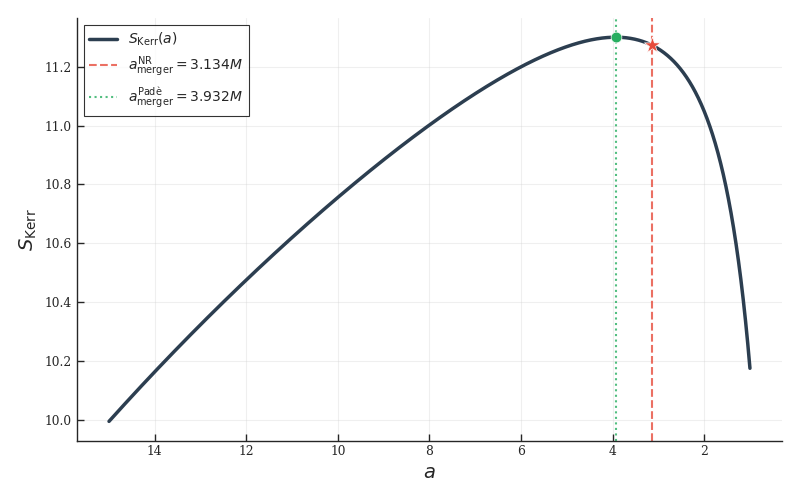

In [113]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})


sort_idx = np.argsort(a_extrap_0PN)
a_sorted = a_extrap_0PN[sort_idx]
ent_sorted = ENT_extrap_0PN[sort_idx]
y_at_merger = np.interp(a_merger, a_sorted, ent_sorted)
y_at_max_entropy = np.interp(a_max_entropy_0PN, a_sorted, ent_sorted)

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(a_extrap_0PN, ENT_extrap_0PN, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.scatter(a_merger, y_at_merger, marker='*', s=150, color='#e74c3c', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter(a_max_entropy_0PN, y_at_max_entropy, marker='o', s=60, color='#27ae60', zorder=5, edgecolor='white', linewidth=0.5)
ax.axvline(a_merger, color="#e74c3c", linestyle="--", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_entropy_0PN, color="#27ae60", linestyle=":", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm Padè}}={a_max_entropy_0PN:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$") 
ax.set_ylabel(r"$S_{\rm Kerr}$")           
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()